<a href="https://colab.research.google.com/github/pedrotamani/05-sales-performance-analysis/blob/main/sales_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Importación de Librerías y dataset

In [2]:
# Librerías para manejar los datos
import pandas as pd
import numpy as np

# Librerías para visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

In [5]:
# Load dataset

data = "/content/Sample - Superstore.csv"
df = pd.read_csv(data, encoding='latin1')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#2. Exploración inicial del dataset

In [6]:
df.shape

(9994, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


#3. Limpieza de datos

##3.1. Convertir Fechas

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

##3.2. Valores Nulos. Si hubiera valores nulos utilizamos: df = df.dropna()

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


##3.3. Creamos columnas útiles para el análisis

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

#4. Descripción General del Negocio (Overview)

In [13]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009


# 5. Ventas por categoría

##¿Qué categorías generan más ingresos?

In [15]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_by_category

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


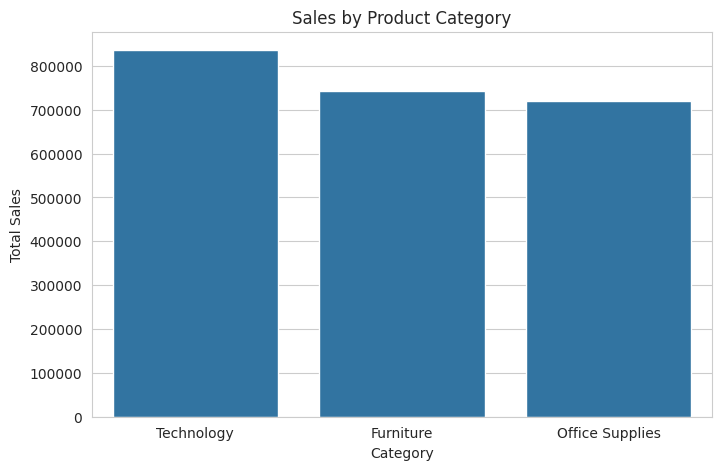

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

#6. Ventas por región

##¿Qué categorías generan más ingresos?

In [17]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_by_category

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


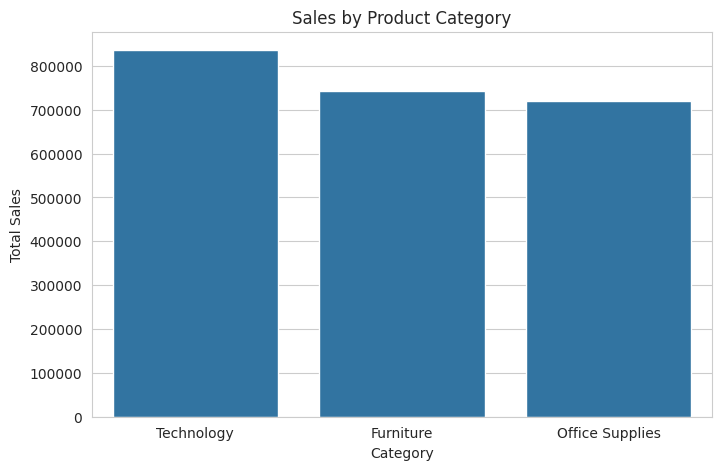

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

#7. Top productos

##¿Qué productos generan más ingresos?

In [20]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


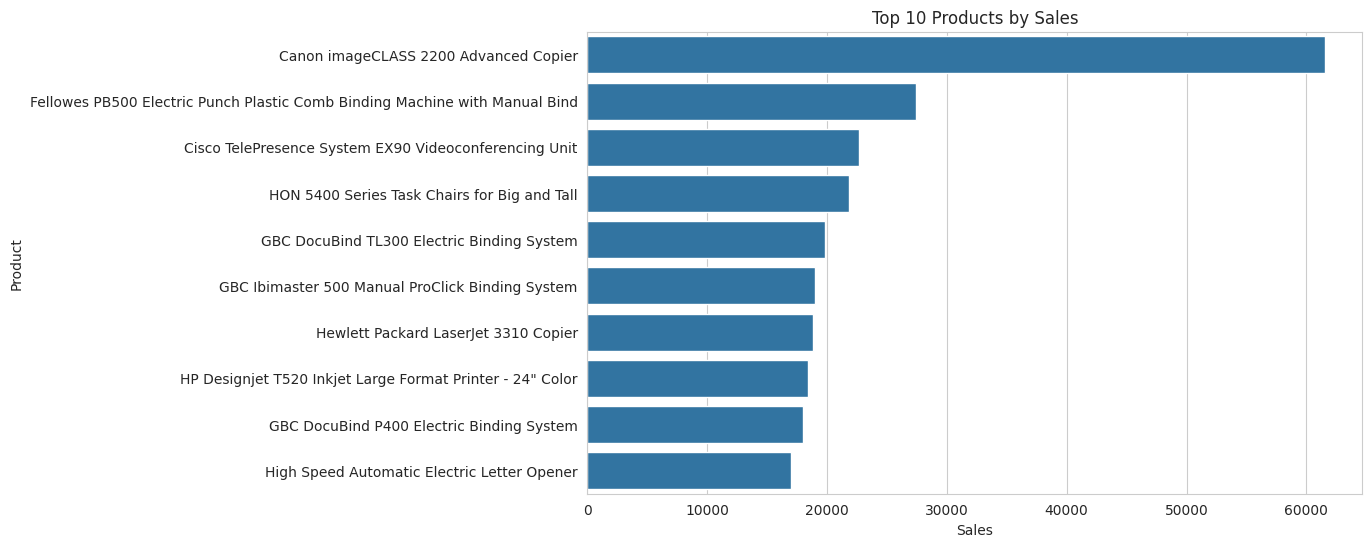

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(y=top_products.index, x=top_products.values)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

#8. Análisis de rentabilidad

##¿Qué categorías generan más profit?

In [22]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

profit_by_category

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


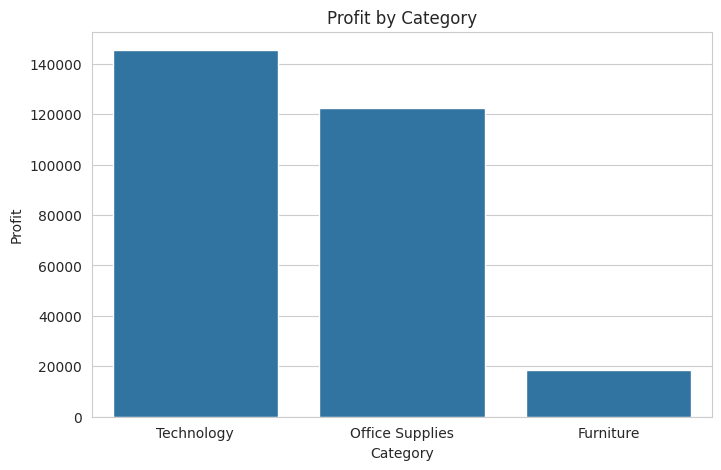

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x=profit_by_category.index, y=profit_by_category.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

#9. Análisis temporal

##¿Cómo evolucionan las ventas en el tiempo?

In [24]:
monthly_sales = df.groupby('Month Name')['Sales'].sum()

Ordenamos por meses

In [25]:
month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

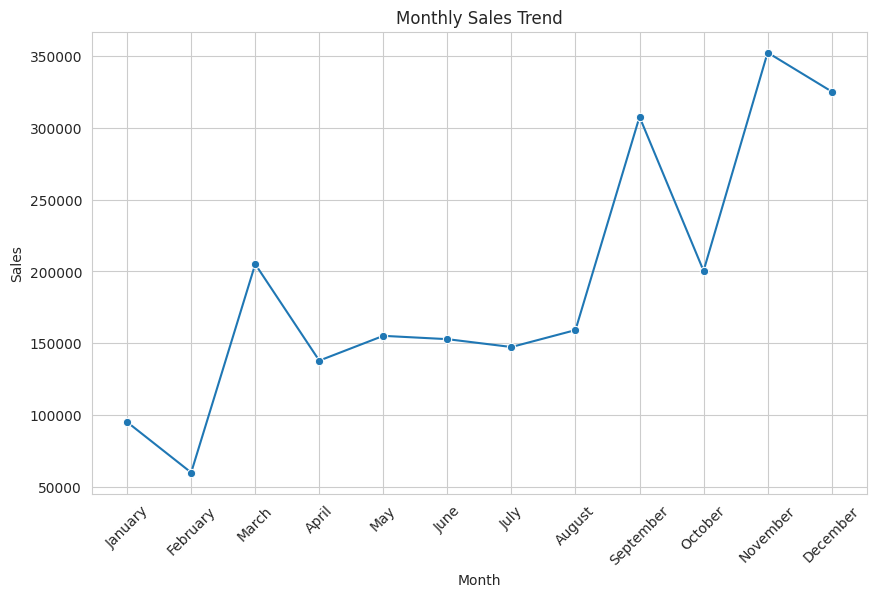

In [26]:
plt.figure(figsize=(10,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

#10. Segmentación de clientes

## ¿Qué tipo de cliente genera más ventas?

In [27]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

sales_by_segment

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


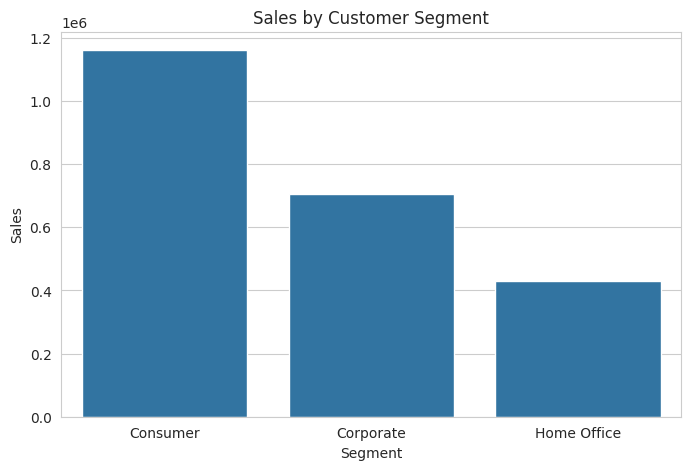

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

#11. Análisis Ventas vs Utilidad

##¿Más ventas siempre significan más utilidad?

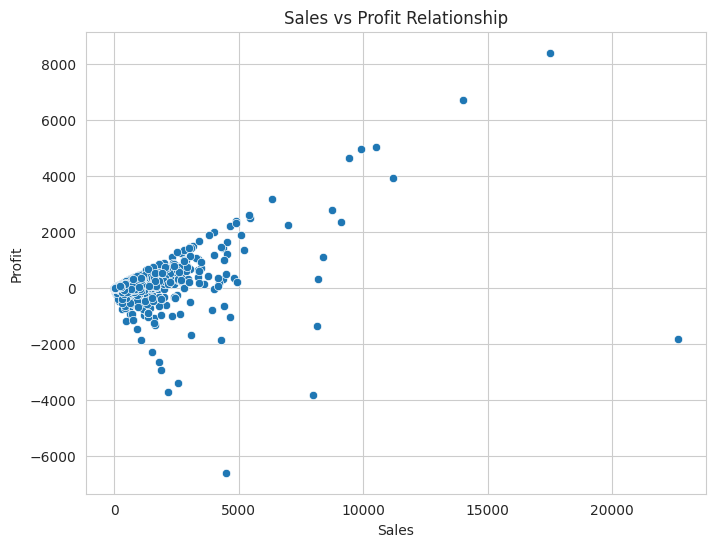

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='Sales', y='Profit')

plt.title("Sales vs Profit Relationship")

plt.show()

#12. Heatmap de correlación

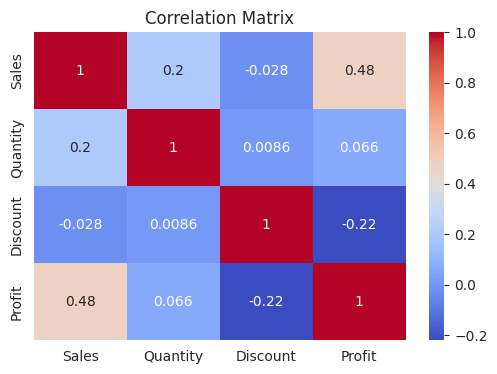

In [30]:
corr = df[['Sales','Quantity','Discount','Profit']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

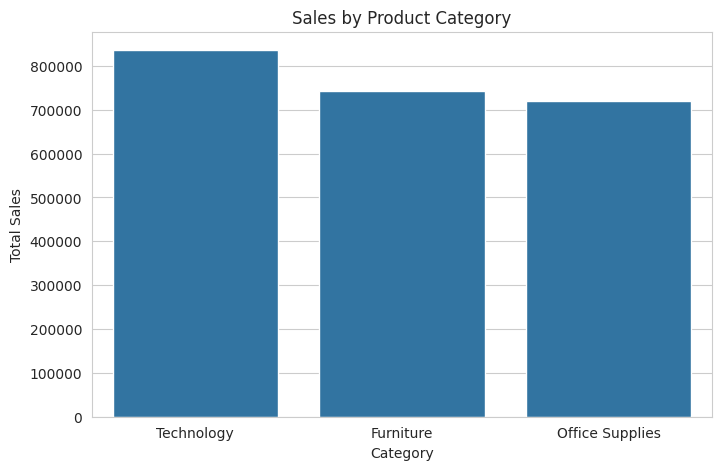

In [33]:
import os

# Create images folder if it doesn't exist
os.makedirs("../images", exist_ok=True)

# Save figure
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("../images/sales_by_category.png")

plt.show()